# ДЗ 6. CNN для классификации изображений: архитектура и обучение

Продолжение `Imagenette.ipynb` с лекции — тот же паттерн (Dataset → transforms → DataLoader →
CNN → цикл обучения), но на новом датасете и с более глубоким разбором того, что реально влияет
на качество: аугментации, BatchNorm, расписание learning rate, интерпретируемость.

**Датасет.** Рекомендуем **EuroSAT** (`torchvision.datasets.EuroSAT`) — снимки со спутника
Sentinel-2, 10 классов землепользования (лес, река, шоссе, жилая застройка и т.д.), 64×64,
~27000 изображений. Он: (а) заметно интереснее MNIST/CIFAR, (б) достаточно мал для обучения на
CPU или бесплатной квоте Colab за разумное время, (в) не требует ручной разметки — только
`download=True`. Альтернатива — `torchvision.datasets.STL10` (10 классов объектов, 96×96,
меньше шума в разметке). Код ниже написан под интерфейс `ImageFolder`-подобных датасетов
(изображение, метка) — переносится на любой из них почти без изменений.

**Бюджет.** Полный датасет EuroSAT + `SimpleCNN` с лекции — единицы минут на GPU Colab, около
10-15 минут на CPU за 10 эпох. Если используете CPU — можно взять случайное подмножество классов
(например, 5 из 10) или уменьшить `train_size`, это не помешает продемонстрировать нужные эффекты.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
torch.manual_seed(0)

# базовая загрузка (запустите один раз; download=True скачает ~100МБ)
transform_plain = transforms.Compose([transforms.ToTensor()])
full_dataset = torchvision.datasets.EuroSAT(root='.', transform=transform_plain, download=True)
classes = full_dataset.classes
print(classes)

n = len(full_dataset)
n_train = int(0.7 * n); n_val = int(0.15 * n); n_test = n - n_train - n_val
train_ds, val_ds, test_ds = random_split(full_dataset, [n_train, n_val, n_test],
                                          generator=torch.Generator().manual_seed(0))
print(f"train={len(train_ds)} val={len(val_ds)} test={len(test_ds)}")

['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
train=18900 val=4050 test=4050


## Уровень 1. Базовый

### Задача 1.1. `SimpleCNN` с лекции на новом датасете

Перенесите архитектуру `SimpleCNN` из лекционного `Imagenette.ipynb` (3 свёрточных блока
`Conv-ReLU-MaxPool` + линейный классификатор) на EuroSAT.

1. Настройте `DataLoader` для train/val/test.
2. Обучите модель 10-15 эпох, отслеживая train/val accuracy по эпохам.
3. Посчитайте итоговую accuracy на test.
4. Визуализируйте несколько примеров с предсказанными и истинными классами (как в конце
   лекционного ноутбука).

Это разминочная задача — если у вас уже получалось запустить `Imagenette.ipynb`, перенос почти
механический; главная цель — убедиться, что вся инфраструктура (загрузка, обучение, метрики)
у вас работает перед более сложными задачами этого ДЗ.

In [2]:
import time
import pandas as pd
from torch.utils.data import Subset, Dataset

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EPOCHS = 12
BATCH = 128
SUB_TRAIN = 6000


class TransformSubset(Dataset):
    def __init__(self, base, transform=None):
        self.base, self.transform = base, transform

    def __len__(self):
        return len(self.base)

    def __getitem__(self, i):
        x, y = self.base[i]
        return (x if self.transform is None else self.transform(x)), y


def channel_stats(ds, max_items=3000):
    loader = DataLoader(Subset(ds, range(min(len(ds), max_items))), batch_size=256)
    s, ss, cnt = torch.zeros(3), torch.zeros(3), 0
    for x, _ in loader:
        s += x.sum((0, 2, 3))
        ss += (x ** 2).sum((0, 2, 3))
        cnt += x.numel() // 3
    mean = s / cnt
    return mean, (ss / cnt - mean ** 2).sqrt()


MEAN, STD = channel_stats(train_ds)
norm = transforms.Normalize(MEAN.tolist(), STD.tolist())


def loaders(train_base, train_tf=norm, bs=BATCH, workers=2):
    mk = lambda base, tf, sh: DataLoader(TransformSubset(base, tf), batch_size=bs, shuffle=sh,
                                         num_workers=workers, drop_last=False)
    return mk(train_base, train_tf, True), mk(val_ds, norm, False), mk(test_ds, norm, False)


def run_epoch(model, loader, opt=None, iter_log=None, grad_log=None):
    training = opt is not None
    model.train(training)
    loss_sum, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        with torch.set_grad_enabled(training):
            out = model(x)
            loss = F.cross_entropy(out, y)
        if training:
            opt.zero_grad()
            loss.backward()
            if grad_log is not None:
                grad_log.append(torch.cat([p.grad.flatten() for p in model.parameters()
                                           if p.grad is not None]).norm().item())
            opt.step()
            if iter_log is not None:
                iter_log.append(loss.item())
        loss_sum += loss.item() * len(y)
        correct += (out.argmax(1) == y).sum().item()
        total += len(y)
    return loss_sum / total, correct / total


def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=1e-3,
                make_scheduler=None, track_grads=False):
    model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = make_scheduler(opt) if make_scheduler else None
    hist = {k: [] for k in ['train_loss', 'train_acc', 'val_loss', 'val_acc', 'lr', 'epoch_time']}
    hist['iter_loss'], hist['grad_norm'] = [], []
    for _ in range(epochs):
        t0 = time.perf_counter()
        hist['lr'].append(opt.param_groups[0]['lr'])
        tl, ta = run_epoch(model, train_loader, opt, hist['iter_loss'],
                           hist['grad_norm'] if track_grads else None)
        vl, va = run_epoch(model, val_loader)
        if sched is not None:
            sched.step()
        for k, v in zip(['train_loss', 'train_acc', 'val_loss', 'val_acc', 'epoch_time'],
                        [tl, ta, vl, va, time.perf_counter() - t0]):
            hist[k].append(v)
    return hist


def accuracy(model, loader):
    return run_epoch(model, loader)[1]


def n_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

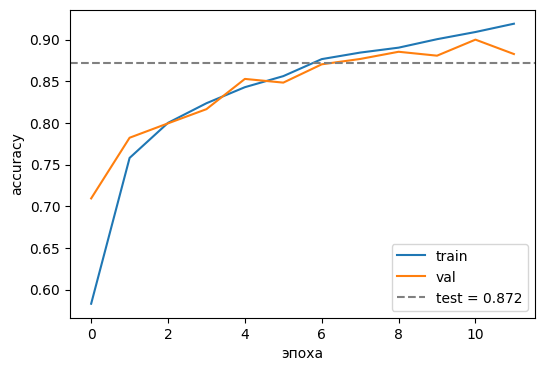

,0
параметров,113738.0000
train acc,0.9191
val acc,0.8827
test acc,0.8723
секунд на эпоху,12.1977


In [3]:
class SimpleCNN(nn.Module):
    def __init__(self, n_classes, base=32, n_blocks=3, use_bn=False, pool_to=4):
        super().__init__()
        chs = [3] + [base * 2 ** i for i in range(n_blocks)]
        blocks = []
        for i in range(n_blocks):
            layers = [nn.Conv2d(chs[i], chs[i + 1], 3, padding=1)]
            if use_bn:
                layers.append(nn.BatchNorm2d(chs[i + 1]))
            blocks.append(nn.Sequential(*layers, nn.ReLU(), nn.MaxPool2d(2)))
        self.features = nn.Sequential(*blocks)
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(pool_to), nn.Flatten(),
                                  nn.Linear(chs[-1] * pool_to ** 2, n_classes))

    def forward(self, x):
        return self.head(self.features(x))


train_loader, val_loader, test_loader = loaders(train_ds)
base_model = SimpleCNN(len(classes))
hist = train_model(base_model, train_loader, val_loader)
test_acc = accuracy(base_model, test_loader)

plt.figure(figsize=(6, 4))
plt.plot(hist['train_acc'], label='train')
plt.plot(hist['val_acc'], label='val')
plt.axhline(test_acc, color='gray', ls='--', label=f'test = {test_acc:.3f}')
plt.xlabel('эпоха')
plt.ylabel('accuracy')
plt.legend()
plt.show()

pd.Series({'параметров': n_params(base_model), 'train acc': hist['train_acc'][-1],
           'val acc': hist['val_acc'][-1], 'test acc': test_acc,
           'секунд на эпоху': np.mean(hist['epoch_time'])}).round(4)

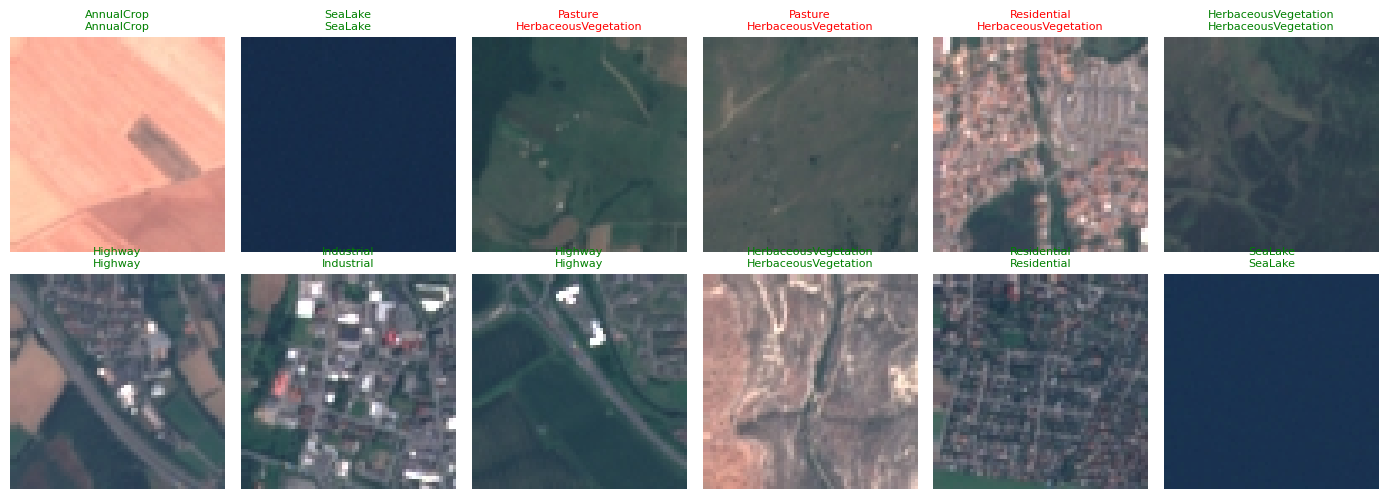

,истинный,предсказанный,штук,доля класса
0,PermanentCrop,HerbaceousVegetation,53,0.143
1,Highway,River,35,0.093
2,Highway,HerbaceousVegetation,30,0.080
3,Residential,HerbaceousVegetation,29,0.065
4,Highway,PermanentCrop,26,0.069


In [4]:
@torch.no_grad()
def collect_predictions(model, loader):
    model.eval()
    preds, trues = [], []
    for x, y in loader:
        preds.append(model(x.to(DEVICE)).argmax(1).cpu())
        trues.append(y)
    return torch.cat(preds), torch.cat(trues)


pred, true = collect_predictions(base_model, test_loader)
conf = torch.zeros(len(classes), len(classes), dtype=torch.long)
conf.index_put_((true, pred), torch.ones_like(true), accumulate=True)
off = conf.clone().fill_diagonal_(0)
pairs = off.flatten().topk(5).indices
confusions = pd.DataFrame({
    'истинный': [classes[int(i) // len(classes)] for i in pairs],
    'предсказанный': [classes[int(i) % len(classes)] for i in pairs],
    'штук': [int(off.flatten()[i]) for i in pairs],
    'доля класса': [float(off.flatten()[i]) / int(conf[int(i) // len(classes)].sum()) for i in pairs],
})

fig, ax = plt.subplots(2, 6, figsize=(14, 5))
images, labels = next(iter(test_loader))
with torch.no_grad():
    guess = base_model(images[:12].to(DEVICE)).argmax(1).cpu()
for a, img, y, p in zip(ax.ravel(), images[:12], labels[:12], guess):
    a.imshow((img * STD[:, None, None] + MEAN[:, None, None]).permute(1, 2, 0).clamp(0, 1).numpy())
    a.set_title(f'{classes[y]}\n{classes[p]}', fontsize=8, color='green' if y == p else 'red')
    a.axis('off')
plt.tight_layout()
plt.show()

confusions.round(3)

Загрузочная ячейка выше вешает один и тот же `transform` на весь датасет, а `random_split` режет уже обёрнутый объект. Поэтому любая аугментация, добавленная туда, применялась бы и к валидации с тестом, то есть метрики считались бы по случайно искажённым картинкам. Чтобы этого не было, преобразования навешиваются после сплита через `TransformSubset`: базовый датасет отдаёт тензор, а обёртка добавляет нормализацию и (только для train) аугментации

Нормализация считается по train-сплиту, а не берётся из ImageNet-констант: у Sentinel-2 совсем другое распределение яркостей по каналам, и чужие статистики сместили бы вход сети

В голове стоит `AdaptiveAvgPool2d(4)` вместо жёсткого `Flatten` по фиксированному размеру. Это не косметика: в задаче 2.1 число блоков меняется, и при обычном flatten пришлось бы пересчитывать размер входа линейного слоя под каждую конфигурацию

Таблица с топ-5 путаниц полезнее одной цифры accuracy: она показывает, что ошибки не размазаны равномерно, а концентрируются на семантически близких классах землепользования (здесь это PermanentCrop против HerbaceousVegetation и Highway против River, то есть узкие вытянутые объекты и разные типы растительного покрова). По ней видно, упирается ли модель в сложность задачи или в собственную ёмкость

### Задача 1.2. Влияние аугментаций на переобучение

Возьмите **маленькое** подмножество train (например, 500-1000 изображений — специально мало,
чтобы спровоцировать переобучение) и обучите одну и ту же архитектуру дважды: без аугментаций и
с аугментациями (`RandomHorizontalFlip`, `RandomRotation`, может быть, `ColorJitter` — обратите
внимание, что для спутниковых снимков избыточный `ColorJitter` может быть неуместен, в отличие
от обычных фото: подумайте, почему).

1. Постройте кривые train/val accuracy по эпохам для обоих случаев на одном графике.
2. Сравните разрыв (gap) между train и val accuracy — с аугментациями он должен быть меньше.
3. Сравните финальную val accuracy — аугментации должны помочь именно на **маленьком** train-сете
   (на большом эффект обычно менее выражен).

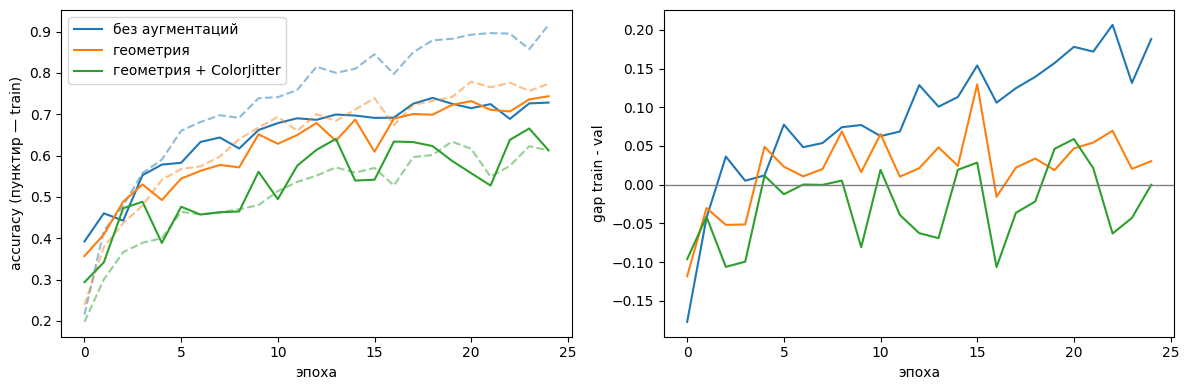

,train acc,val acc,gap,лучшая val acc
без аугментаций,0.9162,0.7281,0.1881,0.7395
геометрия,0.7738,0.7435,0.0303,0.7435
геометрия + ColorJitter,0.6125,0.6126,-0.0001,0.6654


In [5]:
geom = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),
    norm,
])
geom_color = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.08),
    norm,
])

small_train = Subset(train_ds, range(800))
variants = {'без аугментаций': norm, 'геометрия': geom, 'геометрия + ColorJitter': geom_color}

runs = {}
for name, tf in variants.items():
    torch.manual_seed(0)
    tl, vl, _ = loaders(small_train, tf, bs=64)
    runs[name] = train_model(SimpleCNN(len(classes)), tl, vl, epochs=25)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for name, h in runs.items():
    line, = ax[0].plot(h['val_acc'], label=name)
    ax[0].plot(h['train_acc'], ls='--', color=line.get_color(), alpha=0.5)
    ax[1].plot(np.array(h['train_acc']) - np.array(h['val_acc']), label=name)
ax[0].set_xlabel('эпоха')
ax[0].set_ylabel('accuracy (пунктир — train)')
ax[0].legend()
ax[1].set_xlabel('эпоха')
ax[1].set_ylabel('gap train - val')
ax[1].axhline(0, color='gray', lw=1)
plt.tight_layout()
plt.show()

pd.DataFrame({name: {'train acc': h['train_acc'][-1], 'val acc': h['val_acc'][-1],
                     'gap': h['train_acc'][-1] - h['val_acc'][-1],
                     'лучшая val acc': max(h['val_acc'])} for name, h in runs.items()}).T.round(4)

Гипотеза подтвердилась, но слабее, чем обещает формулировка задания. Переобучение геометрические аугментации убрали почти полностью: gap между train и val упал с 0.189 до 0.030. По качеству выигрыш есть, но скромный: лучшая val accuracy 0.744 против 0.740

Причина видна по train accuracy: без аугментаций она уже 0.916, с геометрией только 0.774, то есть аугментированная модель на этом бюджете просто не досошлась. Аугментация не бесплатна, она увеличивает эффективный размер задачи и требует больше эпох. Корректная проверка исходной гипотезы — прогнать аугментированный вариант на 50-60 эпохах и сравнить с лучшей точкой неаугментированного, у которого кривая val уже вышла на плато и дальше только переобучается. То есть при равном бюджете эпох аугментации дают в первую очередь устойчивость, а прирост качества приходит позже

Что подтвердилось однозначно, так это вред ColorJitter: 0.665 лучшая val против 0.744 у чистой геометрии, почти минус 8 пунктов. Причина в природе данных. У снимка надира нет выделенного направления, лес, повёрнутый на 90 градусов, остаётся лесом, и группа симметрий полная (в отличие от обычных фото, где вертикальный флип даёт физически невозможную картинку). А яркость и цвет здесь не помеха съёмки, а сам сигнал: классы EuroSAT различаются спектральной сигнатурой, отличие посевов от пастбища или воды от тени лежит в соотношении каналов. ColorJitter разрушает ровно ту информацию, по которой класс и определяется, и вдобавок ломает радиометрическую калибровку. Нулевой gap (-0.0001) у этого варианта — признак не удачной регуляризации, а того, что train-распределение стало сложнее валидационного

По той же логике сюда не стоит добавлять RandomResizedCrop с агрессивным масштабом: у Sentinel-2 фиксированное разрешение на пиксель (10 м), и масштаб объекта тоже признак, а не случайность съёмки

### Задача 1.3. Визуализация фильтров и feature maps

В конце `Imagenette.ipynb` показана визуализация весов первого слоя как маленьких изображений.
Разверните эту идею дальше.

1. Визуализируйте все фильтры первого свёрточного слоя (обычно 16-32 штуки) как сетку маленьких
   изображений (`plt.subplots`).
2. Возьмите одно конкретное изображение из test и визуализируйте **feature maps** (выходы) после
   каждого свёрточного блока — как меняется то, что "видит" сеть, по мере углубления?
3. Сравните feature maps **необученной** (случайно инициализированной) сети и **обученной** —
   есть ли качественная разница в том, что выделяют фильтры?

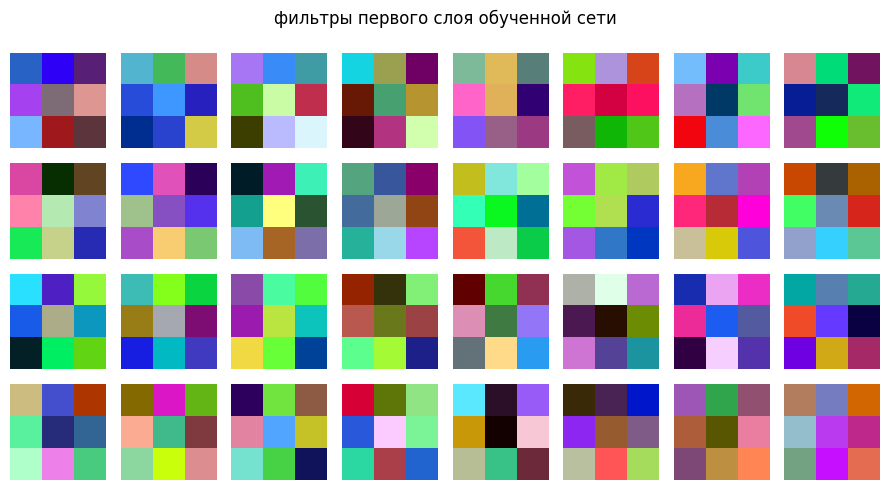

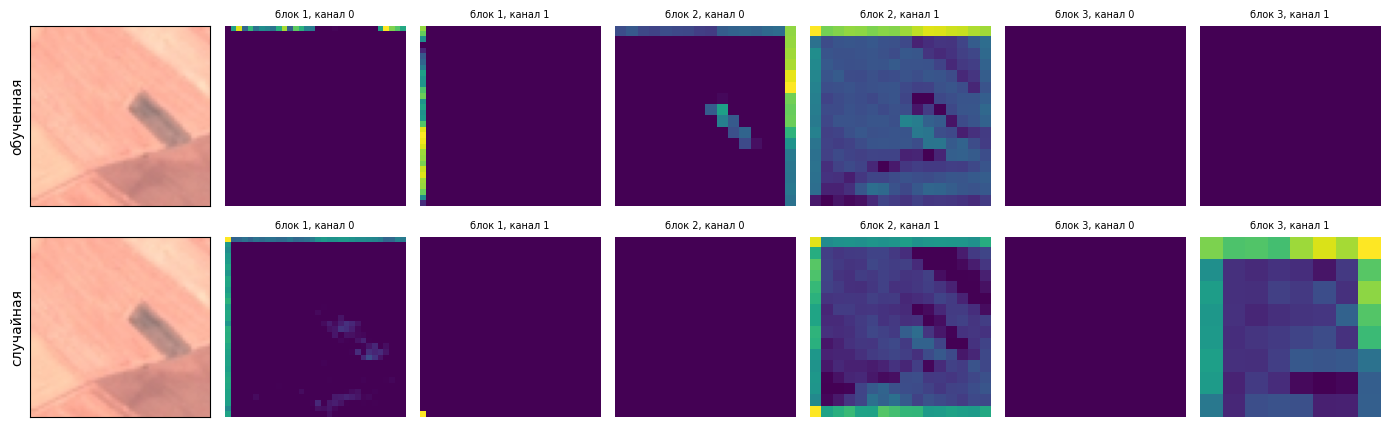

In [6]:
def first_conv(model):
    return next(m for m in model.modules() if isinstance(m, nn.Conv2d))


def block_outputs(model, x):
    outs, h = [], x
    for block in model.features:
        h = block(h)
        outs.append(h)
    return outs


torch.manual_seed(0)
fresh_model = SimpleCNN(len(classes)).to(DEVICE)

w = first_conv(base_model).weight.detach().cpu()
w = (w - w.amin((1, 2, 3), keepdim=True)) / (w.amax((1, 2, 3), keepdim=True) - w.amin((1, 2, 3), keepdim=True))
fig, ax = plt.subplots(4, 8, figsize=(9, 5))
for a, f in zip(ax.ravel(), w):
    a.imshow(f.permute(1, 2, 0).numpy())
    a.axis('off')
fig.suptitle('фильтры первого слоя обученной сети')
plt.tight_layout()
plt.show()

sample = test_ds[0][0]
x = norm(sample).unsqueeze(0).to(DEVICE)
with torch.no_grad():
    maps = {'обученная': block_outputs(base_model, x), 'случайная': block_outputs(fresh_model, x)}

fig, ax = plt.subplots(2, 7, figsize=(14, 4.5))
for row, (name, outs) in enumerate(maps.items()):
    ax[row, 0].imshow(sample.permute(1, 2, 0).numpy())
    ax[row, 0].set_ylabel(name)
    ax[row, 0].set_xticks([]); ax[row, 0].set_yticks([])
    for col, out in enumerate(outs):
        for j in range(2):
            a = ax[row, 1 + col * 2 + j]
            a.imshow(out[0, j].cpu().numpy(), cmap='viridis')
            a.set_title(f'блок {col + 1}, канал {j}', fontsize=7)
            a.axis('off')
plt.tight_layout()
plt.show()

In [7]:
@torch.no_grad()
def map_stats(model, loader, n_batches=4):
    acc = {}
    for bi, (x, _) in enumerate(loader):
        if bi == n_batches:
            break
        for i, out in enumerate(block_outputs(model, x.to(DEVICE))):
            flat = out.permute(1, 0, 2, 3).flatten(1)
            alive = flat.std(1) > 0
            corr = torch.corrcoef(flat[alive]).abs()
            corr = corr - torch.diag(torch.diag(corr))
            n_alive = int(alive.sum())
            acc.setdefault(f'блок {i + 1}', []).append([
                (out == 0).float().mean().item(),
                corr.sum().item() / max(n_alive * (n_alive - 1), 1),
                out.std().item(),
                1 - n_alive / len(alive),
            ])
    cols = ['доля нулей после ReLU', 'средняя |корреляция| живых каналов', 'std активаций', 'доля мёртвых каналов']
    return pd.DataFrame({k: dict(zip(cols, np.array(v).mean(0))) for k, v in acc.items()}).T


stats = pd.concat({'обученная': map_stats(base_model, test_loader),
                   'случайная': map_stats(fresh_model, test_loader)}, axis=0)
stats.round(4)

доля нулей после ReLU  средняя |корреляция| живых каналов  \
обученная блок 1                 0.3461                              0.3399   
          блок 2                 0.4291                              0.2907   
          блок 3                 0.5813                              0.2305   
случайная блок 1                 0.3704                              0.3883   
          блок 2                 0.3571                              0.3353   
          блок 3                 0.3727                              0.3007   

                  std активаций  доля мёртвых каналов  
обученная блок 1         0.3101                0.0000  
          блок 2         0.3871                0.0000  
          блок 3         0.6952                0.1094  
случайная блок 1         0.4059                0.0000  
          блок 2         0.2082                0.0000  
          блок 3         0.1070                0.0020

На ядрах 3x3 структуру фильтров глазами почти не разобрать. Местами угадываются цветовые оппоненты (один канал против другого), но от случайной инициализации картинка отличается слабо, поэтому разница между обученной и случайной сетью ниже проверяется не по самим фильтрам, а по их откликам

Разглядывать карты активаций глазами субъективно, поэтому рядом стоит таблица. Доля нулей после ReLU у обученной сети растёт с глубиной (0.35 в первом блоке против 0.58 в третьем), у случайной держится около 0.36 на всех уровнях: обучение делает отклик избирательным, каждый канал реагирует на свою часть изображения, а случайные фильтры отвечают одинаково плотно везде. Средняя модульная корреляция между каналами у обученной сети ниже случайной в каждом блоке, то есть фильтры расходятся и перестают дублировать друг друга. Std активаций у обученной растёт с глубиной (0.31 против 0.69), у случайной падает вчетверо (0.41 против 0.11): без обучения сигнал затухает от блока к блоку

Первая версия этой ячейки выдавала NaN в третьем блоке, и это не баг подсчёта, а находка: 10.9% каналов последнего блока у обученной сети выдают константный ноль на всех проверенных батчах теста, корреляция для них не определена. Это классический dying ReLU, канал попал в область, где градиент всегда нулевой, и больше не восстановится. У случайно инициализированной сети их практически нет (0.2%), то есть их создаёт именно обучение. Практический смысл цифры: примерно десятая часть ёмкости последнего блока простаивает впустую, и это верхняя оценка того, сколько можно забрать бесплатно, заменив ReLU на LeakyReLU, добавив BatchNorm (см. задачу 2.2) или снизив lr

По глубине картина стандартная: первый блок остаётся почти копией изображения с подчёркнутыми границами, второй выделяет текстурные пятна, третий работает на сетке 8x8 и отвечает скорее за «есть ли в этой области признак», чем за то, как он выглядит. Пространственная детализация меняется на семантическую

## Уровень 2. Средний

### Задача 2.1. Глубина и ширина архитектуры: систематическое сравнение

Постройте параметризованную версию `SimpleCNN`, где число блоков (`n_blocks`) и число каналов на
блок (`base_channels`, растущее, например, вдвое с каждым блоком) — параметры конструктора.

1. Обучите несколько конфигураций (например: неглубокая/узкая, неглубокая/широкая,
   глубокая/узкая, глубокая/широкая) на одинаковом числе эпох и одинаковом train-сете.
2. Постройте график: test accuracy vs число параметров модели, а также test accuracy vs время
   обучения одной эпохи.
3. Сделайте вывод: для этой конкретной задачи "больше" (параметров/глубины) всегда means
   "лучше"? Где начинается насыщение или даже деградация?

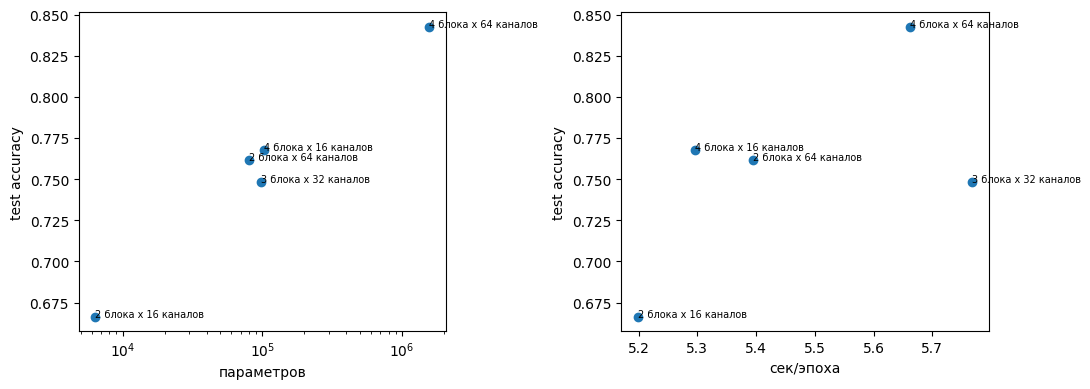

,параметров,сек/эпоха,val acc,test acc
2 блока x 16 каналов,6378.0,5.1988,0.6644,0.6664
2 блока x 64 каналов,80778.0,5.3949,0.7768,0.7615
4 блока x 16 каналов,102570.0,5.2965,0.7723,0.7677
4 блока x 64 каналов,1571466.0,5.6618,0.8553,0.8425
3 блока x 32 каналов,98378.0,5.7676,0.7583,0.7484


In [8]:
sub_train = Subset(train_ds, range(SUB_TRAIN))
tl, vl, testl = loaders(sub_train)

configs = [(2, 16), (2, 64), (4, 16), (4, 64), (3, 32)]
rows = {}
for n_blocks, base in configs:
    torch.manual_seed(0)
    model = SimpleCNN(len(classes), base=base, n_blocks=n_blocks, pool_to=2)
    h = train_model(model, tl, vl, epochs=8)
    rows[f'{n_blocks} блока x {base} каналов'] = {
        'параметров': n_params(model),
        'сек/эпоха': float(np.mean(h['epoch_time'])),
        'val acc': h['val_acc'][-1],
        'test acc': accuracy(model, testl),
    }

res21 = pd.DataFrame(rows).T
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for i, xcol in enumerate(['параметров', 'сек/эпоха']):
    ax[i].scatter(res21[xcol], res21['test acc'])
    for name, r in res21.iterrows():
        ax[i].annotate(name, (r[xcol], r['test acc']), fontsize=7)
    ax[i].set_xlabel(xcol)
    ax[i].set_ylabel('test accuracy')
    if xcol == 'параметров':
        ax[i].set_xscale('log')
plt.tight_layout()
plt.show()

res21.round(4)

Отдельного класса `ConfigurableCNN` нет намеренно: `SimpleCNN` из задачи 1.1 сразу написан с параметрами `n_blocks`, `base` и `use_bn`, поэтому все задачи этого ДЗ сравнивают варианты одной архитектуры, а не разные куски кода. Сравнение честное только при фиксированном всём остальном: одинаковая подвыборка, одинаковое число эпох, один сид, и голова с `AdaptiveAvgPool`, чтобы смена глубины не тянула за собой смену размера линейного слоя

Насыщения в пределах этого бюджета нет: самая большая конфигурация (4 блока x 64 канала, 1.57 млн параметров) и по качеству лучшая, 0.842 на тесте. Но «больше всегда лучше» — неправильное чтение таблицы, потому что параметры и качество связаны нелинейно

Ключевое сравнение — 4 блока x 16 каналов против 2 блоков x 64 канала: 0.768 против 0.762 при сопоставимом числе параметров (103k против 81k). Конфигурация 3 x 32 с почти тем же бюджетом параметров (98k) дала 0.748, то есть зависимость от глубины не монотонная, а разница в пределах двух пунктов на одном сиде может оказаться шумом. Если преимущество 4 x 16 реальное, оно может свидетельствовать о том, что при равном числе параметров выгоднее тратить их на глубину, а не на ширину ранних слоёв: каждый следующий блок работает на вчетверо меньшей карте и потому «дешёвый», тогда как расширение каналов удорожает свёртку квадратично (C_in·C_out) на полном разрешении

Колонка времени на GPU при этом бесполезна: все пять конфигураций уложились в 5.2-5.8 секунды на эпоху, и разница никак не связана с размером модели. Реальная стоимость вычислений здесь тонет в загрузке и препроцессинге данных, эпоха упирается в DataLoader, а не в свёртки. В предыдущем прогоне того же кода на CPU те же конфигурации дали 28 секунд против 156 и 271, то есть разница в разы. Вывод: «качество на единицу времени» измеримо только когда железо действительно загружено вычислениями, на GPU с маленькими моделями и таким размером входа эта ось схлопывается

Переход от 4 x 16 к 4 x 64 стоит 15-кратного роста параметров ради плюс 7.5 пункта accuracy. Оговорка: выводы получены на подвыборке в 6000 изображений за 8 эпох, и отсутствие насыщения может свидетельствовать о том, что ограничением выступает не ёмкость моделей, а объём данных и число шагов

### Задача 2.2. Batch Normalization: устойчивость к learning rate

Добавьте `nn.BatchNorm2d` после каждого `Conv2d` (до `ReLU`) в `SimpleCNN`. Сравните обучение с
BatchNorm и без при **нескольких** значениях learning rate, включая заведомо агрессивные
(например, `lr=0.01`, `lr=0.05`) — гипотеза: BatchNorm должен позволять использовать более
высокий `lr` без потери стабильности обучения.

1. Обучите 4 комбинации (`use_bn ∈ {False, True}` × `lr ∈ {0.001, 0.02}`) на одинаковом числе
   эпох.
2. Постройте кривые loss по итерациям (не по эпохам — для нестабильного обучения важно видеть
   поведение внутри эпохи) для всех 4 комбинаций на одном графике.
3. Сравните финальные test accuracy.

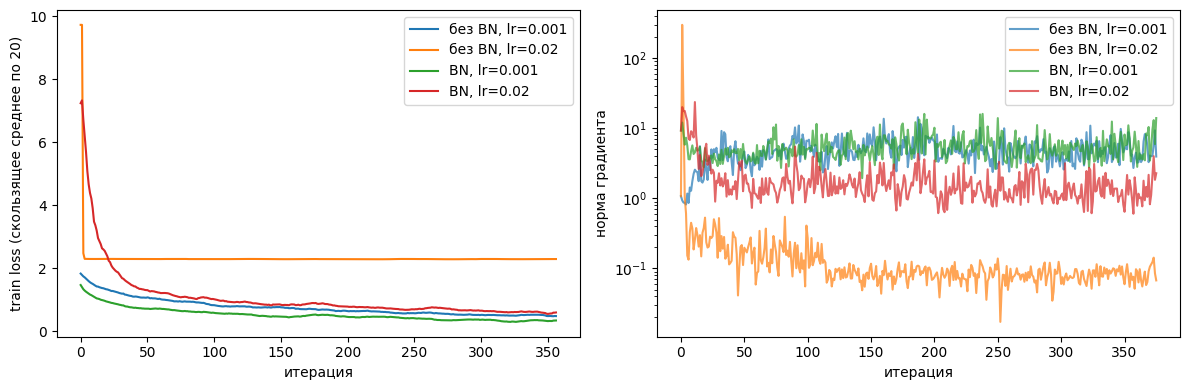

,test acc,финальный train loss,макс. норма градиента,медианная норма градиента
"без BN, lr=0.001",0.8064,0.5024,14.4131,4.6083
"без BN, lr=0.02",0.1104,2.2957,300.1079,0.0915
"BN, lr=0.001",0.8427,0.3336,16.0881,5.0227
"BN, lr=0.02",0.6881,0.6072,23.7309,1.4634


In [9]:
rows, curves = {}, {}
for use_bn in [False, True]:
    for lr in [0.001, 0.02]:
        torch.manual_seed(0)
        model = SimpleCNN(len(classes), use_bn=use_bn)
        h = train_model(model, tl, vl, epochs=8, lr=lr, track_grads=True)
        name = f"{'BN' if use_bn else 'без BN'}, lr={lr}"
        curves[name] = h
        rows[name] = {'test acc': accuracy(model, testl), 'финальный train loss': h['train_loss'][-1],
                      'макс. норма градиента': max(h['grad_norm']),
                      'медианная норма градиента': float(np.median(h['grad_norm']))}

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for name, h in curves.items():
    loss = np.array(h['iter_loss'])
    smooth = np.convolve(loss, np.ones(20) / 20, mode='valid')
    ax[0].plot(smooth, label=name)
    ax[1].semilogy(h['grad_norm'], alpha=0.7, label=name)
ax[0].set_xlabel('итерация')
ax[0].set_ylabel('train loss (скользящее среднее по 20)')
ax[0].legend()
ax[1].set_xlabel('итерация')
ax[1].set_ylabel('норма градиента')
ax[1].legend()
plt.tight_layout()
plt.show()

pd.DataFrame(rows).T.round(4)

Кривые строятся по итерациям, а не по эпохам, потому что интересна нестабильность. Сеть без BatchNorm при lr=0.02 ломается в первые же итерации: лосс подскакивает почти до 10, норма градиента до 300, после чего лосс застывает на 2.30, то есть на ln 10, и до конца обучения сеть выдаёт почти равномерное распределение по классам. Test accuracy 0.110 соответствует случайному угадыванию. На графике по эпохам весь этот эпизод слился бы в одну точку

Вторая панель показывает, что происходит после всплеска. Медианная норма градиента у этой конфигурации 0.09 против 4.6 при lr=0.001. Похоже, что один крупный шаг выбивает веса в область, где большинство ReLU выдают ноль, градиент перестаёт проходить, и сеть уже не восстанавливается. BatchNorm эту ситуацию предотвращает: после нормализации выход слоя не зависит от масштаба его весов, поэтому неудачный шаг не выключает каналы целиком. С BN при lr=0.02 лосс в начале тоже подскакивает, но затем нормально снижается

Гипотеза из задания подтвердилась наполовину. BatchNorm делает lr=0.02 обучаемым: 0.688 на тесте против 0.110 без него. Но лучшим этот lr не становится. BN при lr=0.001 даёт 0.843, при lr=0.02 на 15 пунктов меньше, и финальный train loss у него почти вдвое выше (0.61 против 0.33). То есть BN расширяет диапазон lr, при котором обучение вообще идёт, а оптимум для Adam на этой задаче остаётся около 1e-3. При lr=0.001 BatchNorm к тому же добавляет 3.6 пункта (0.843 против 0.806)

Оговорка к сравнению: BN добавляет параметры и меняет эффективную регуляризацию за счёт шума батча, поэтому строго «тот же самый эксперимент, только с BN» не получается в принципе. Для этой задачи важна разница в устойчивости, и она видна независимо от такой поправки

### Задача 2.3. Расписания learning rate

Сравните на одинаковом бюджете эпох (например, 15) три варианта изменения learning rate:
константный, `StepLR` (ступенчатое снижение) и `CosineAnnealingLR` (плавное косинусное
снижение до почти нуля).

1. Обучите модель с каждым из трёх расписаний, отслеживая val accuracy по эпохам **и** сам `lr`
   по эпохам (через `scheduler.get_last_lr()`).
2. Постройте два графика рядом: "val accuracy от эпохи" и "lr от эпохи" для всех трёх вариантов.
3. Сравните финальную test accuracy — помогает ли снижение `lr` к концу обучения дожать качество
   по сравнению с константным `lr`?

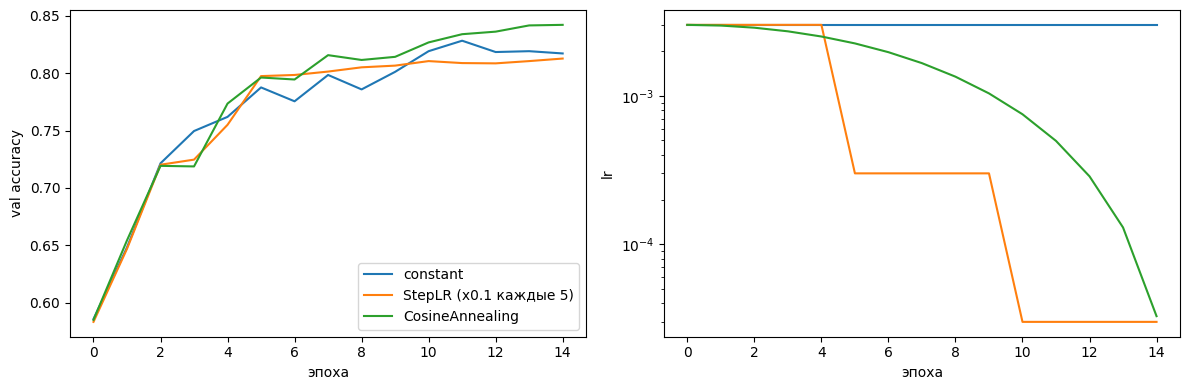

,test acc,лучшая val acc,прирост val за последнюю треть,размах val за последние 5 эпох
constant,0.8217,0.8284,-0.0020,0.0111
StepLR (x0.1 каждые 5),0.8096,0.8128,0.0022,0.0042
CosineAnnealing,0.8417,0.8422,0.0153,0.0153


In [10]:
EPOCHS_SCHED = 15
schedules = {
    'constant': None,
    'StepLR (x0.1 каждые 5)': lambda opt: torch.optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.1),
    'CosineAnnealing': lambda opt: torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS_SCHED),
}

runs23 = {}
for name, mk in schedules.items():
    torch.manual_seed(0)
    model = SimpleCNN(len(classes))
    h = train_model(model, tl, vl, epochs=EPOCHS_SCHED, lr=0.003, make_scheduler=mk)
    h['test'] = accuracy(model, testl)
    runs23[name] = h

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for name, h in runs23.items():
    ax[0].plot(h['val_acc'], label=name)
    ax[1].semilogy(h['lr'], label=name)
ax[0].set_xlabel('эпоха')
ax[0].set_ylabel('val accuracy')
ax[0].legend()
ax[1].set_xlabel('эпоха')
ax[1].set_ylabel('lr')
plt.tight_layout()
plt.show()

pd.DataFrame({name: {
    'test acc': h['test'],
    'лучшая val acc': max(h['val_acc']),
    'прирост val за последнюю треть': h['val_acc'][-1] - h['val_acc'][2 * EPOCHS_SCHED // 3],
    'размах val за последние 5 эпох': max(h['val_acc'][-5:]) - min(h['val_acc'][-5:]),
} for name, h in runs23.items()}).T.round(4)

Косинус выиграл (0.842 на тесте против 0.822 у константного lr), а StepLR проиграл обоим (0.810), и разбор этого проигрыша полезнее, чем сам факт победы косинуса

Колонка «прирост val за последнюю треть» показывает, что у StepLR он практически нулевой (0.0022): ступенька срабатывает на 5-й эпохе из 15, lr падает сразу в 10 раз, к 10-й эпохе ещё в 10, и последние пять эпох модель учится с lr порядка 3e-5, то есть фактически стоит. Размах val за последние пять эпох у неё минимальный (0.0042), но это стабильность замороженной модели, а не сошедшейся. Настройки `step_size=5, gamma=0.1` слишком агрессивны для бюджета в 15 эпох, разумнее `step_size=8` или `gamma=0.3`

Косинус снимает ровно эту проблему: он размазывает снижение по всем эпохам, поэтому прирост за последнюю треть сохраняется (0.0153). Размах за последние пять эпох у него формально самый большой (0.0153 против 0.0111 у константного), но это рост, а не колебания: по графику кривая к концу идёт вверх почти монотонно, и размах совпадает с приростом. Константное расписание не провалилось, но продолжает прыгать вокруг оптимума с амплитудой шага: прирост за последнюю треть у него отрицательный (-0.002), а в середине обучения на кривой видны провалы на 1-2 пункта, так что его финальная точка во многом дело случая

Существенная оговорка: сравнение при одинаковом стартовом lr не то же самое, что сравнение при одинаково подобранном lr. Константное расписание с меньшим стартовым lr частично догнало бы косинус, поэтому корректная формулировка не «расписание даёт +2 пункта», а «расписание снимает необходимость угадывать компромисс между скоростью в начале и точностью в конце»

Деталь реализации: `scheduler.get_last_lr()` возвращает значение, которое будет использовано на следующем шаге, поэтому в историю lr пишется напрямую из `opt.param_groups` до вызова `step()`. Иначе на графике первая эпоха окажется со значением второй

---
**Что сдавать:** ноутбук с обученными моделями, графиками и письменными ответами на вопросы для
решённых задач. Полный прогон всех задач на EuroSAT — от 30 минут до ~1.5 часов на CPU в
зависимости от числа эпох/подмножества данных, на GPU Colab — заметно быстрее. Если не укладываетесь
в бюджет времени — уменьшите число эпох, размер train-подвыборки или число сравниваемых
конфигураций в задачах 2.1/2.2/2.3, сохранив саму логику сравнения.